In [12]:
import os
import glob
import json
import pandas as pd
import numpy as np
from datetime import datetime

# Paths
data_dir = os.path.join('..', 'data')
sample_files = glob.glob(os.path.join(data_dir, '*.json'))[:5]  # Load first 5 files

# Helper functions
def clean_numeric(val):
    """Convert string or mixed types to float, handling % and commas."""
    if pd.isna(val):
        return np.nan
    if isinstance(val, (int, float)):
        return val
    val = str(val).replace(',', '').replace('%', '').strip()
    if val in ['', '-', 'null', 'None']:
        return np.nan
    try:
        return float(val)
    except:
        return np.nan

def clean_year(val):
    """Convert year strings like 'Mar 2024' or 'TTM' to datetime or keep as string."""
    if val == 'TTM':
        return 'TTM'
    try:
        return datetime.strptime(val, "%b %Y")
    except:
        return val

# Store merged data
all_cashflow = []
all_balancesheet = []
all_profitloss = []

# Read & clean
for file_path in sample_files:
    with open(file_path, 'r') as f:
        data = json.load(f)
    
    company_id = data['company']['id']
    
    # Cashflow
    if 'cashflow' in data['data']:
        cf_df = pd.DataFrame(data['data']['cashflow'])
        cf_df['year'] = cf_df['year'].apply(clean_year)
        num_cols = ['operating_activity', 'investing_activity', 'financing_activity', 'net_cash_flow']
        for col in num_cols:
            cf_df[col] = cf_df[col].apply(clean_numeric)
        cf_df['company_id'] = company_id
        all_cashflow.append(cf_df)
    
    # Balance sheet
    if 'balancesheet' in data['data']:
        bs_df = pd.DataFrame(data['data']['balancesheet'])
        bs_df['year'] = bs_df['year'].apply(clean_year)
        for col in bs_df.columns:
            if col not in ['year', 'company_id', 'id', 'equity_capital']:
                bs_df[col] = bs_df[col].apply(clean_numeric)
        bs_df['equity_capital'] = bs_df['equity_capital'].apply(clean_numeric)
        bs_df['company_id'] = company_id
        all_balancesheet.append(bs_df)
    
    # Profit & Loss
    if 'profitandloss' in data['data']:
        pl_df = pd.DataFrame(data['data']['profitandloss'])
        pl_df['year'] = pl_df['year'].apply(clean_year)
        for col in pl_df.columns:
            if col not in ['year', 'company_id', 'id']:
                pl_df[col] = pl_df[col].apply(clean_numeric)
        pl_df['company_id'] = company_id
        all_profitloss.append(pl_df)

# Merge into master DataFrames
cashflow_df = pd.concat(all_cashflow, ignore_index=True)
balancesheet_df = pd.concat(all_balancesheet, ignore_index=True)
profitloss_df = pd.concat(all_profitloss, ignore_index=True)

# ===== Basic EDA =====

# 1. Summary stats
print("Cashflow Summary:\n", cashflow_df.describe())
print("\nBalance Sheet Summary:\n", balancesheet_df.describe())
print("\nProfit & Loss Summary:\n", profitloss_df.describe())

# 2. Missing value analysis
print("\nMissing values (Cashflow):\n", cashflow_df.isna().sum())
print("\nMissing values (Balance Sheet):\n", balancesheet_df.isna().sum())
print("\nMissing values (Profit & Loss):\n", profitloss_df.isna().sum())

# 3. Trends (example: yearly sales growth)
sales_trend = (
    profitloss_df.groupby(['company_id', 'year'])['sales']
    .sum()
    .reset_index()
    .sort_values(['company_id', 'year'])
)
print("\nSales Trend:\n", sales_trend)

# Save cleaned data
cashflow_df.to_csv('cashflow_cleaned.csv', index=False)
balancesheet_df.to_csv('balancesheet_cleaned.csv', index=False)
profitloss_df.to_csv('profitloss_cleaned.csv', index=False)


Cashflow Summary:
                id                           year  operating_activity  \
count   66.000000                             66           66.000000   
mean    93.500000  2019-01-25 19:16:21.818181888         3659.909091   
min     61.000000            2012-12-01 00:00:00          -35.000000   
25%     77.250000            2016-03-01 00:00:00          906.750000   
50%     93.500000            2019-03-01 00:00:00         2522.500000   
75%    109.750000            2022-03-01 00:00:00         5437.000000   
max    126.000000            2024-03-01 00:00:00        17626.000000   
std     19.196354                            NaN         3697.858697   

       investing_activity  financing_activity  net_cash_flow  
count           66.000000           66.000000      66.000000  
mean         -4666.803030         1086.333333      79.484848  
min         -21060.000000        -7800.000000   -7550.000000  
25%          -5403.750000         -624.250000     -64.000000  
50%          -319

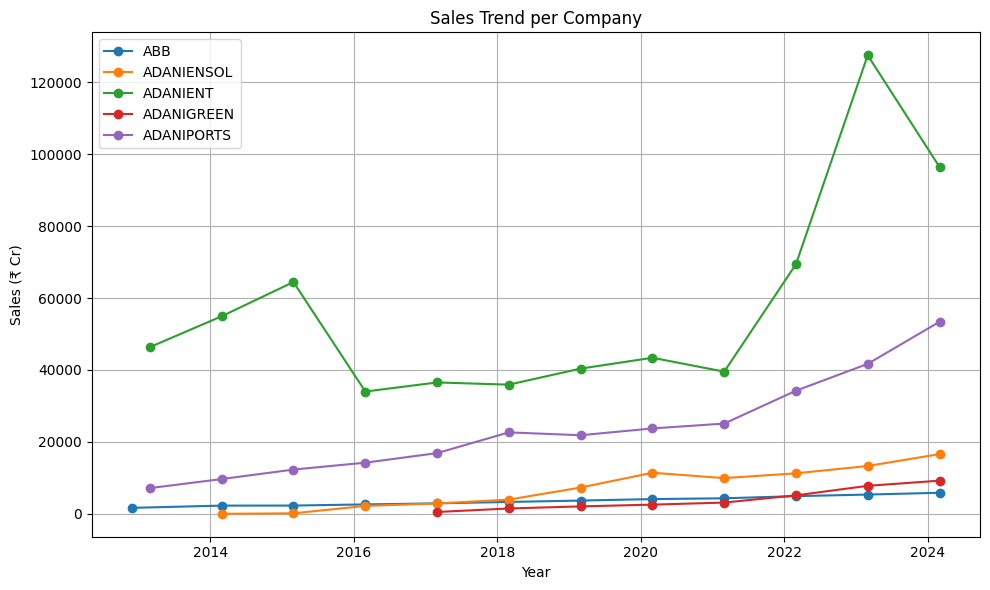

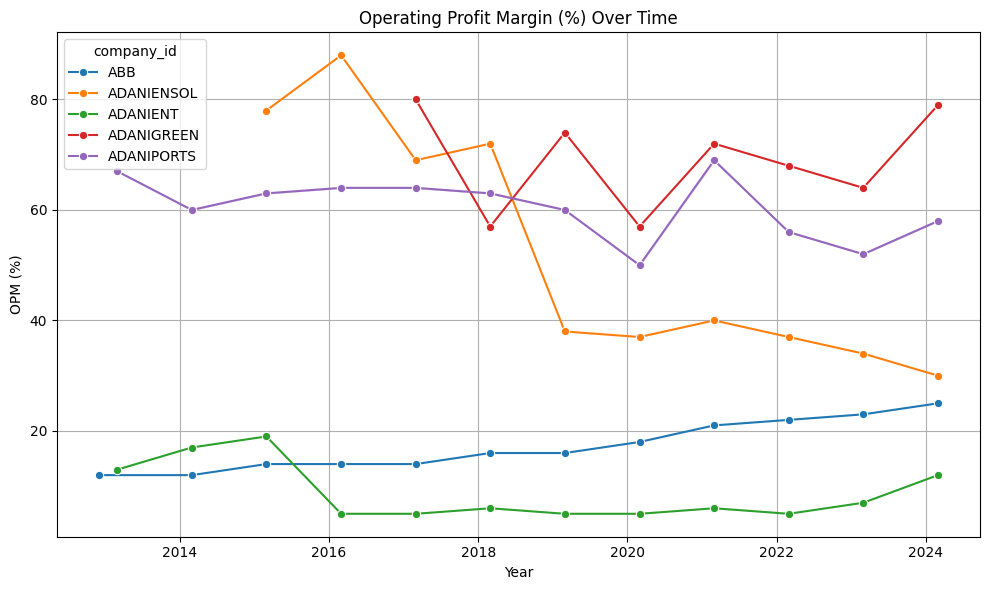

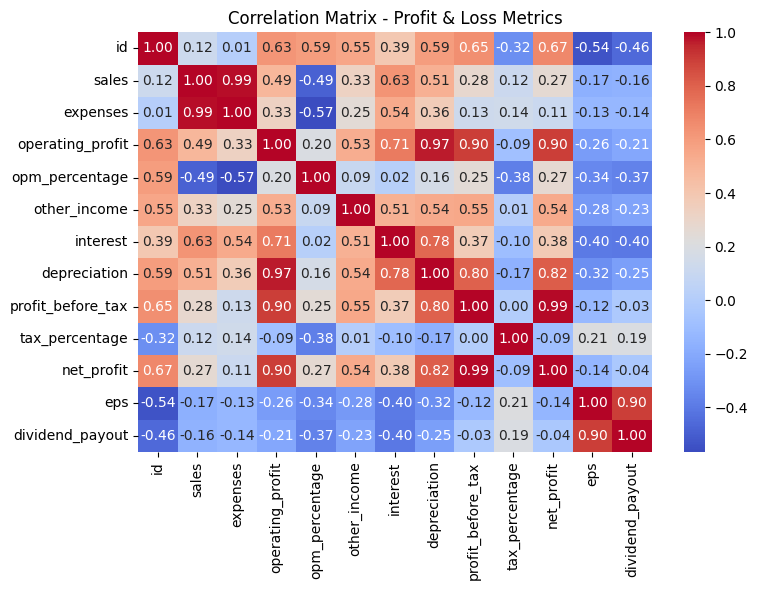


Top companies by average sales growth in sample:
    company_id  avg_sales_growth
1  ADANIENSOL               inf
3  ADANIGREEN          0.515568
4  ADANIPORTS          0.200547
0         ABB          0.121739
2    ADANIENT          0.068806


C:\Users\Chethan\AppData\Local\Temp\ipykernel_7840\1321207930.py:43: RuntimeWarning: divide by zero encountered in scalar divide
  .apply(lambda x: (x['sales'].iloc[-1] / x['sales'].iloc[0])**(1/(len(x)-1)) - 1)
C:\Users\Chethan\AppData\Local\Temp\ipykernel_7840\1321207930.py:43: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x['sales'].iloc[-1] / x['sales'].iloc[0])**(1/(len(x)-1)) - 1)


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Sales trend line plots
plt.figure(figsize=(10, 6))
for cid in sales_trend['company_id'].unique():
    subset = sales_trend[sales_trend['company_id'] == cid]
    # Keep only numeric years
    subset = subset[subset['year'] != 'TTM']
    plt.plot(subset['year'], subset['sales'], marker='o', label=cid)
plt.title("Sales Trend per Company")
plt.xlabel("Year")
plt.ylabel("Sales (₹ Cr)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 2. Profit margin over time (Operating Profit Margin)
pl_margin = profitloss_df.copy()
pl_margin = pl_margin[pl_margin['year'] != 'TTM']
plt.figure(figsize=(10, 6))
sns.lineplot(data=pl_margin, x='year', y='opm_percentage', hue='company_id', marker='o')
plt.title("Operating Profit Margin (%) Over Time")
plt.xlabel("Year")
plt.ylabel("OPM (%)")
plt.grid(True)
plt.tight_layout()
plt.show()

# 3. Correlation heatmap for P&L numeric columns
numeric_pl = profitloss_df.select_dtypes(include=[np.number])
plt.figure(figsize=(8, 6))
sns.heatmap(numeric_pl.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix - Profit & Loss Metrics")
plt.tight_layout()
plt.show()

# 4. Top companies by average sales growth (CAGR-like quick calc)
sales_growth = (
    sales_trend[sales_trend['year'] != 'TTM']
    .groupby('company_id')
    .apply(lambda x: (x['sales'].iloc[-1] / x['sales'].iloc[0])**(1/(len(x)-1)) - 1)
    .reset_index(name='avg_sales_growth')
    .sort_values('avg_sales_growth', ascending=False)
)
print("\nTop companies by average sales growth in sample:\n", sales_growth)


In [8]:
"""
Unified processing pipeline for many company JSONs:
- reads JSON files
- normalizes & cleans sections (cashflow, balancesheet, profitandloss)
- extracts 'analysis' section
- feature engineering (margins, leverage, growths, CAGR)
- caching/incremental behavior
- stores master CSV files + SQLite DB for quick queries
"""

import os
import glob
import json
import re
from datetime import datetime
from pathlib import Path

import pandas as pd
import numpy as np
import sqlite3
from tqdm import tqdm

# CONFIG
data_dir = os.path.join('..', 'data')   # adjust as needed
file_glob = os.path.join(data_dir, '*.json')
process_limit = 5   # set to 5 for testing, or None for all
output_dir = './compiled_output'
os.makedirs(output_dir, exist_ok=True)

# Output filenames
csv_cashflow = os.path.join(output_dir, 'cashflow_master.csv')
csv_balancesheet = os.path.join(output_dir, 'balancesheet_master.csv')
csv_profitloss = os.path.join(output_dir, 'profitloss_master.csv')
csv_analysis = os.path.join(output_dir, 'analysis_master.csv')
csv_meta = os.path.join(output_dir, 'companies_meta.csv')
sqlite_db = os.path.join(output_dir, 'financials.db')

# --- HELPERS ---
def to_num(x):
    """Robust numeric conversion: remove commas, %; convert to float or NaN."""
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, float)):
        return float(x)
    s = str(x).strip()
    if s in ['', '-', 'None', 'null', 'nan', 'NA']:
        return np.nan
    s = s.replace(',', '')
    # capture parentheses as negative e.g. (123)
    if re.match(r'^\(.*\)$', s):
        s = '-' + s[1:-1]
    # strip percent but keep numeric
    s = s.replace('%', '')
    try:
        return float(s)
    except:
        return np.nan

def parse_year_to_dt(y):
    """Keep 'TTM' flagged, parse 'Mar 2024' -> datetime (end of month).
       Returns (dt_or_NaT, is_ttm_flag, original_str)
    """
    if pd.isna(y):
        return (pd.NaT, False, y)
    if isinstance(y, (pd.Timestamp, datetime)):
        return (pd.to_datetime(y), False, str(y))
    s = str(y).strip()
    if s.upper() == 'TTM':
        return (pd.NaT, True, 'TTM')
    # Try formats like 'Mar 2024', 'Mar-2024', '2024-03-31'
    for fmt in ("%b %Y", "%b %Y", "%Y-%m-%d", "%Y"):
        try:
            dt = pd.to_datetime(datetime.strptime(s, fmt))
            return (dt, False, s)
        except:
            pass
    # fallback: try pandas parse
    try:
        dt = pd.to_datetime(s, errors='coerce')
        if pd.isna(dt):
            return (pd.NaT, False, s)
        return (dt, False, s)
    except:
        return (pd.NaT, False, s)

def compute_group_growth(df, company_col='company_id', value_col='sales', year_dt_col='year_dt'):
    """Compute YoY pct_change and simple CAGR between first and last available rows per company."""
    df = df.copy().sort_values([company_col, year_dt_col])
    df['{}_yoy'.format(value_col)] = df.groupby(company_col)[value_col].pct_change()
    # compute CAGR for group if possible
    def cagr(group):
        vals = group[value_col].dropna()
        if len(vals) < 2:
            return np.nan
        first, last = vals.iloc[0], vals.iloc[-1]
        n = len(vals) - 1
        if first <= 0 or n <= 0:
            return np.nan
        return (last / first) ** (1.0 / n) - 1.0
    cagr_df = df.groupby(company_col).apply(lambda g: pd.Series({'{}_cagr'.format(value_col): cagr(g)})).reset_index()
    return df, cagr_df

# --- FILE PROCESSING ---
def process_json_file(path):
    """Return dicts of dataframes for sections and metadata."""
    with open(path, 'r', encoding='utf-8') as f:
        j = json.load(f)
    cid = j.get('company', {}).get('id', Path(path).stem)
    company_meta = j.get('company', {})
    
    # ----- CASHFLOW
    cashflow = pd.DataFrame(j.get('data', {}).get('cashflow', []))
    if not cashflow.empty:
        cashflow['company_id'] = cid
        cashflow['year_orig'] = cashflow['year']
        parsed = cashflow['year_orig'].apply(parse_year_to_dt)
        cashflow['year_dt'] = [p[0] for p in parsed]
        cashflow['is_ttm'] = [p[1] for p in parsed]
        # numeric columns
        for col in ['operating_activity', 'investing_activity', 'financing_activity', 'net_cash_flow']:
            if col in cashflow.columns:
                cashflow[col] = cashflow[col].apply(to_num)
    # ----- BALANCE SHEET
    balancesheet = pd.DataFrame(j.get('data', {}).get('balancesheet', []))
    if not balancesheet.empty:
        balancesheet['company_id'] = cid
        balancesheet['year_orig'] = balancesheet['year']
        parsed = balancesheet['year_orig'].apply(parse_year_to_dt)
        balancesheet['year_dt'] = [p[0] for p in parsed]
        balancesheet['is_ttm'] = [p[1] for p in parsed]
        # numeric columns - skip 'year', 'company_id', 'equity_capital' as needed
        for col in balancesheet.columns:
            if col in ['id', 'company_id', 'year', 'year_orig', 'year_dt', 'is_ttm']:
                continue
            balancesheet[col] = balancesheet[col].apply(to_num)
    # ----- PROFIT & LOSS
    profitloss = pd.DataFrame(j.get('data', {}).get('profitandloss', []))
    if not profitloss.empty:
        profitloss['company_id'] = cid
        profitloss['year_orig'] = profitloss['year']
        parsed = profitloss['year_orig'].apply(parse_year_to_dt)
        profitloss['year_dt'] = [p[0] for p in parsed]
        profitloss['is_ttm'] = [p[1] for p in parsed]
        # numericize
        for col in profitloss.columns:
            if col in ['id', 'company_id', 'year', 'year_orig', 'year_dt', 'is_ttm']:
                continue
            profitloss[col] = profitloss[col].apply(to_num)

    # ----- ANALYSIS (pre-compiled)
    analysis_list = j.get('data', {}).get('analysis', [])
    # normalize: convert list-of-dict to dataframe, and attach company id & top-level meta
    analysis = pd.DataFrame(analysis_list)
    if not analysis.empty:
        analysis['company_id'] = cid
        # optionally add company-level info like roe/roce in company meta, if present
        for k in ('roce_percentage','roe_percentage'):
            if k in company_meta:
                analysis[k] = to_num(company_meta[k])
    
    # ----- Return everything
    return {
        'company_meta': company_meta,
        'cashflow': cashflow if not cashflow.empty else pd.DataFrame(),
        'balancesheet': balancesheet if not balancesheet.empty else pd.DataFrame(),
        'profitloss': profitloss if not profitloss.empty else pd.DataFrame(),
        'analysis': analysis if not analysis.empty else pd.DataFrame()
    }

# --- MAIN PIPELINE ---
def run_pipeline(limit=None, force_reprocess=False):
    files = sorted(glob.glob(file_glob))
    if limit:
        files = files[:limit]

    processed_cids = set()
    all_cf = []
    all_bs = []
    all_pl = []
    all_an = []
    all_meta = []

    for fp in tqdm(files, desc="Processing JSON files"):
        try:
            with open(fp, 'r', encoding='utf-8') as fh:
                head = json.load(fh).get('company', {})
                cid = head.get('id', Path(fp).stem)
        except Exception as e:
            print(f"Failed to read {fp}: {e}")
            continue
        if (cid in processed_cids) and not force_reprocess:
            continue

        out = process_json_file(fp)
        if not out['cashflow'].empty:
            all_cf.append(out['cashflow'])
        if not out['balancesheet'].empty:
            all_bs.append(out['balancesheet'])
        if not out['profitloss'].empty:
            all_pl.append(out['profitloss'])
        if not out['analysis'].empty:
            all_an.append(out['analysis'])
        if out['company_meta']:
            out_meta = out['company_meta'].copy()
            out_meta['company_id'] = cid
            all_meta.append(out_meta)

    # Save master DataFrames as CSV and log potential issues
    def concat_and_save_csv(new_list, csv_path, table_name):
        if new_list:
            new_df = pd.concat(new_list, ignore_index=True)
        else:
            new_df = pd.DataFrame()
        if new_df.empty:
            print(f"No data for {table_name}")
            return new_df
        try:
            new_df.to_csv(csv_path, index=False)
            print(f"Wrote {len(new_df)} rows to {csv_path}")
        except Exception as e:
            print(f"CSV write failed for {table_name}: {e}")
        return new_df

    master_cf = concat_and_save_csv(all_cf, csv_cashflow, 'cashflow')
    master_bs = concat_and_save_csv(all_bs, csv_balancesheet, 'balancesheet')
    master_pl = concat_and_save_csv(all_pl, csv_profitloss, 'profitloss')
    master_an = concat_and_save_csv(all_an, csv_analysis, 'analysis')

    # Save metadata about companies as CSV
    if all_meta:
        meta_df = pd.DataFrame(all_meta)
        # Drop columns with dict/list types
        for col in meta_df.columns:
            if meta_df[col].apply(lambda x: isinstance(x, (dict, list))).any():
                print(f"Dropping column '{col}' due to unsupported type for CSV.")
                meta_df = meta_df.drop(columns=[col])
        try:
            meta_df.to_csv(csv_meta, index=False)
            print(f"Wrote companies meta to {csv_meta}")
        except Exception as e:
            print(f"CSV write failed for meta_df: {e}")
    else:
        meta_df = pd.DataFrame()
        print("No meta_df to process or meta_df is empty.")

    # --- FEATURE ENGINEERING on master PL and BS ---
    if not master_pl.empty:
        if 'year_dt' not in master_pl.columns:
            master_pl['year_dt'] = pd.NaT
        master_pl['opm_calc'] = master_pl.apply(lambda r: (r['operating_profit'] / r['sales']) if (pd.notna(r.get('operating_profit')) and pd.notna(r.get('sales')) and r['sales'] != 0) else np.nan, axis=1)
        master_pl['npm_calc'] = master_pl.apply(lambda r: (r['net_profit'] / r['sales']) if (pd.notna(r.get('net_profit')) and pd.notna(r.get('sales')) and r['sales'] != 0) else np.nan, axis=1)
        master_pl['interest_cov'] = master_pl.apply(lambda r: (r['operating_profit'] / r['interest']) if (pd.notna(r.get('operating_profit')) and pd.notna(r.get('interest')) and r['interest'] != 0) else np.nan, axis=1)
        master_pl = master_pl.sort_values(['company_id','year_dt'])
        master_pl['sales_yoy'] = master_pl.groupby('company_id')['sales'].pct_change()
        master_pl['netprofit_yoy'] = master_pl.groupby('company_id')['net_profit'].pct_change()
        def compute_cagr(series):
            s = series.dropna()
            if len(s) < 2 or s.iloc[0] <= 0:
                return np.nan
            n = len(s) - 1
            return (s.iloc[-1] / s.iloc[0]) ** (1.0 / n) - 1.0
        cagr_sales = master_pl.groupby('company_id').apply(lambda g: compute_cagr(g.sort_values('year_dt')['sales'])).reset_index()
        cagr_sales.columns = ['company_id','sales_cagr']
        cagr_net = master_pl.groupby('company_id').apply(lambda g: compute_cagr(g.sort_values('year_dt')['net_profit'])).reset_index()
        cagr_net.columns = ['company_id','netprofit_cagr']
    else:
        cagr_sales = pd.DataFrame()
        cagr_net = pd.DataFrame()

    if not master_bs.empty:
        master_bs['leverage'] = master_bs.apply(lambda r: (r.get('borrowings') / r.get('total_assets')) if (pd.notna(r.get('borrowings')) and pd.notna(r.get('total_assets')) and r.get('total_assets') != 0) else np.nan, axis=1)
    # write results to sqlite for quick queries
    try:
        conn = sqlite3.connect(sqlite_db)
        if not master_cf.empty:
            master_cf.to_sql('cashflow', conn, if_exists='replace', index=False)
        if not master_bs.empty:
            master_bs.to_sql('balancesheet', conn, if_exists='replace', index=False)
        if not master_pl.empty:
            master_pl.to_sql('profitloss', conn, if_exists='replace', index=False)
        if not master_an.empty:
            master_an.to_sql('analysis', conn, if_exists='replace', index=False)
        if not meta_df.empty:
            meta_df.to_sql('companies_meta', conn, if_exists='replace', index=False)
        if not cagr_sales.empty:
            cagr_sales.to_sql('sales_cagr', conn, if_exists='replace', index=False)
        if not cagr_net.empty:
            cagr_net.to_sql('netprofit_cagr', conn, if_exists='replace', index=False)
        conn.close()
        print(f"Wrote SQLite DB to {sqlite_db}")
    except Exception as e:
        print("SQLite write failed:", e)

    return {
        'cashflow': master_cf,
        'balancesheet': master_bs,
        'profitloss': master_pl,
        'analysis': master_an,
        'meta': meta_df,
        'sales_cagr': cagr_sales,
        'net_cagr': cagr_net
    }

# Run (use limit=5 while testing)
if __name__ == '__main__':
    results = run_pipeline(limit=process_limit, force_reprocess=False)
    print("Done. Master files placed in:", output_dir)


Processing JSON files:   0%|          | 0/5 [00:00<?, ?it/s]

Processing JSON files: 100%|██████████| 5/5 [00:00<00:00, 125.46it/s]

Wrote 66 rows to ./compiled_output\cashflow_master.csv
Wrote 60 rows to ./compiled_output\balancesheet_master.csv
Wrote 73 rows to ./compiled_output\profitloss_master.csv
Wrote 12 rows to ./compiled_output\analysis_master.csv
Wrote companies meta to ./compiled_output\companies_meta.csv
Wrote SQLite DB to ./compiled_output\financials.db
Done. Master files placed in: ./compiled_output



C:\Users\Chethan\AppData\Local\Temp\ipykernel_11492\3146503879.py:262: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cagr_sales = master_pl.groupby('company_id').apply(lambda g: compute_cagr(g.sort_values('year_dt')['sales'])).reset_index()
C:\Users\Chethan\AppData\Local\Temp\ipykernel_11492\3146503879.py:264: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cagr_net = master_pl.groupby('company_id').apply(lambda g: co